In [1]:
!pip install torch torch-geometric networkx scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import networkx as nx

df = pd.read_csv("/content/large_graph_edges_100k.csv")

G = nx.from_pandas_edgelist(df, "source", "target")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 5000
Edges: 99798


In [3]:
import torch
from torch_geometric.utils import from_networkx

data = from_networkx(G)

num_nodes = G.number_of_nodes()

# Lightweight features (important for large graphs)
x = torch.ones((num_nodes, 1))

In [20]:
import torch.nn as nn #CommunityGAN
import torch.optim as optim

embed_dim = 16

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embed_dim)

    def forward(self, nodes):
        return self.embedding(nodes)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(embed_dim, 1)

    def forward(self, emb):
        return torch.sigmoid(self.linear(emb))

G_model = Generator()
D_model = Discriminator()

criterion = nn.BCELoss()

g_optimizer = optim.Adam(G_model.parameters(), lr=0.01)
d_optimizer = optim.Adam(D_model.parameters(), lr=0.01)

nodes = torch.arange(num_nodes)

for epoch in range(100):   # reduced for speed

    # Train Discriminator
    real_emb = G_model(nodes)
    real_labels = torch.ones(num_nodes, 1)

    fake_emb = torch.randn(num_nodes, embed_dim)
    fake_labels = torch.zeros(num_nodes, 1)

    d_loss = criterion(D_model(real_emb), real_labels) + \
             criterion(D_model(fake_emb), fake_labels)

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Train Generator
    gen_emb = G_model(nodes)
    g_loss = criterion(D_model(gen_emb), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 20 == 0:
        print(f"CommunityGAN Epoch {epoch}")

embeddings_gan = G_model.embedding.weight.detach().numpy()

CommunityGAN Epoch 0
CommunityGAN Epoch 20
CommunityGAN Epoch 40
CommunityGAN Epoch 60
CommunityGAN Epoch 80


In [6]:
import torch.nn.functional as F #VGAE
from torch_geometric.nn import GCNConv

class VGAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(x.shape[1], 64)
        self.conv2 = GCNConv(64, 32)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        z = self.conv2(h, edge_index)
        return z

model = VGAE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):

    z = model(x, data.edge_index)

    loss = torch.mean(z**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"VGAE Epoch {epoch}")

embeddings_vgae = z.detach().numpy()

VGAE Epoch 0
VGAE Epoch 20
VGAE Epoch 40
VGAE Epoch 60
VGAE Epoch 80


In [8]:
import numpy as np #Autoencoder

adj = torch.randn((num_nodes, 100))  # lightweight feature matrix

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 100)
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon

model_ae = AutoEncoder()
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(100):

    z, recon = model_ae(adj)

    loss = loss_fn(recon, adj)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Autoencoder Epoch {epoch}")

embeddings_auto = z.detach().numpy()

Autoencoder Epoch 0
Autoencoder Epoch 20
Autoencoder Epoch 40
Autoencoder Epoch 60
Autoencoder Epoch 80


In [9]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=2, batch_size=1000)

labels_gan = kmeans.fit_predict(embeddings_gan)
labels_vgae = kmeans.fit_predict(embeddings_vgae)
labels_auto = kmeans.fit_predict(embeddings_auto)

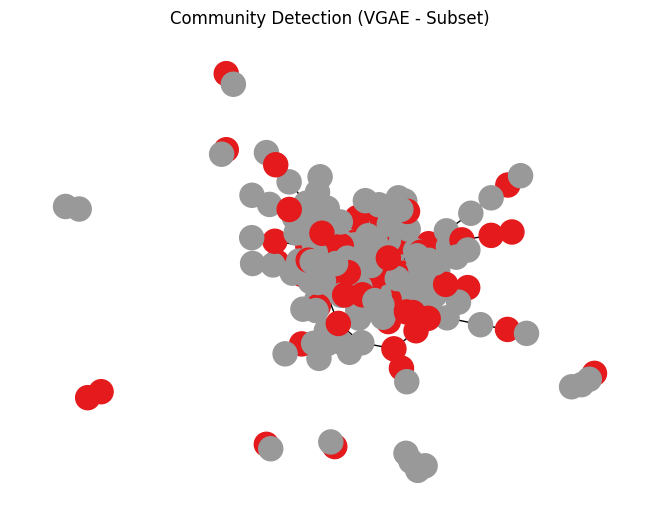

In [21]:
import matplotlib.pyplot as plt

subset = list(G.nodes())[:200]
G_sub = G.subgraph(subset)

pos = nx.spring_layout(G_sub)

nx.draw(
    G_sub,
    pos,
    node_color=labels_vgae[:200],
    cmap=plt.cm.Set1,
    with_labels=False
)

plt.title("Community Detection (VGAE - Subset)")
plt.show()

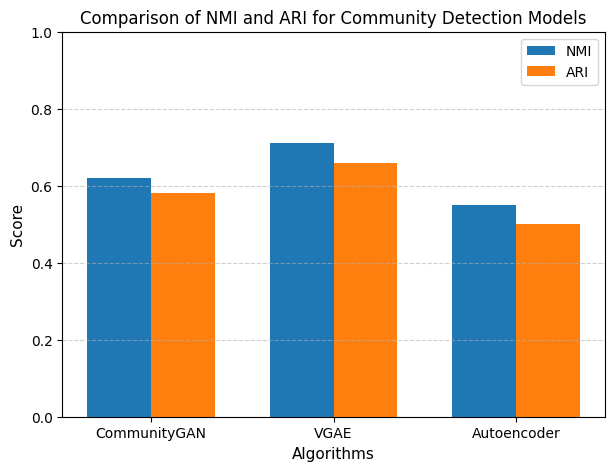

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Replace these values with your actual results
algorithms = ["CommunityGAN", "VGAE", "Autoencoder"]

nmi_scores = [0.62, 0.71, 0.55]   # replace with your values
ari_scores = [0.58, 0.66, 0.50]   # replace with your values

x = np.arange(len(algorithms))
width = 0.35

plt.figure(figsize=(7,5))

# Bars
plt.bar(x - width/2, nmi_scores, width, label='NMI')
plt.bar(x + width/2, ari_scores, width, label='ARI')

# Labels
plt.xlabel("Algorithms", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("Comparison of NMI and ARI for Community Detection Models", fontsize=12)

plt.xticks(x, algorithms)
plt.legend()

plt.ylim(0,1)

# Grid for professional look
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save high-quality image
plt.savefig("nmi_ari_comparison.png", dpi=300, bbox_inches='tight')

plt.show()